In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import signal

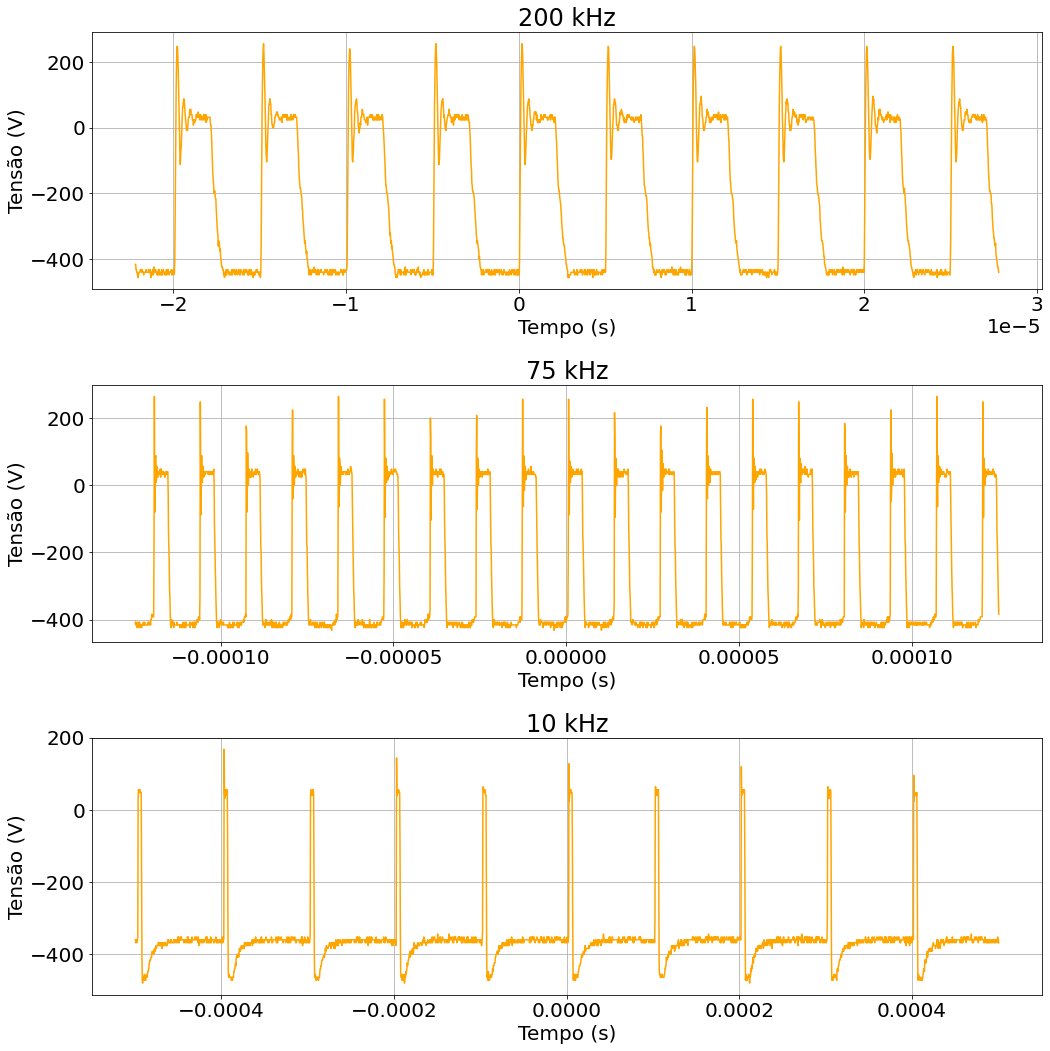

In [2]:
plt.rcParams['figure.figsize'] = [15,15]
plt.rcParams['font.size'] = 20

y1 = np.loadtxt('Pinnacle Plus/200kHz/curva_original.txt')
t1 = y1[:,0]
y12 = y1[:,1]

y2 = np.loadtxt('Pinnacle Plus/75kHz/curva_original.txt')
t2 = y2[:,0]
y22 = y2[:,1]

y3 = np.loadtxt('Pinnacle Plus/10kHz/curva_original.txt')
t3 = y3[:,0]
y32 = y3[:,1]

plt.subplot(3,1,1)
plt.title('200 kHz')
plt.plot(t1, y12, c='orange')
plt.grid()
plt.xlabel('Tempo (s)')
plt.ylabel('Tensão (V)')

plt.subplot(3,1,2)
plt.title('75 kHz')
plt.plot(t2, y22, c='orange')
plt.grid()
plt.xlabel('Tempo (s)')
plt.ylabel('Tensão (V)')

plt.subplot(3,1,3)
plt.title('10 kHz')
plt.plot(t3, y32, c='orange')
plt.grid()
plt.xlabel('Tempo (s)')
plt.ylabel('Tensão (V)')

plt.tight_layout()

Text(0, 0.5, 'Tensão (V)')

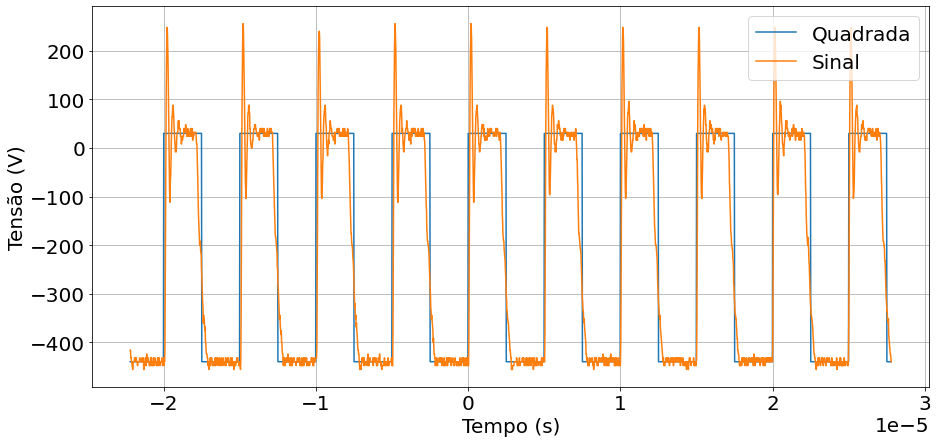

In [3]:
plt.rcParams['figure.figsize'] = [15,7]
plt.rcParams['font.size'] = 20

n = 2500
T = 200e3 * 2 * np.pi
x = np.linspace(-2.22e-5, 2.778e-5, n)
a = 235
y1 = a * signal.square(x*T) - 205

y_exp = np.loadtxt('Pinnacle Plus/200kHz/curva_original.txt')
t = y_exp[:,0]
y2 = y_exp[:,1]

# Transformada quadrada
fft1 = np.fft.fft(y1)
freqs1 = np.fft.fftfreq(n, t[1] - t[0])

# Transformada original
fft2 = np.fft.fft(y2)
freqs2 = np.fft.fftfreq(n, t[1] - t[0])

plt.plot(x, y1)
plt.plot(t, y2)
plt.grid()
plt.legend(("Quadrada",'Sinal'))
plt.xlabel('Tempo (s)')
plt.ylabel('Tensão (V)')


(0.0, 10000000.0)

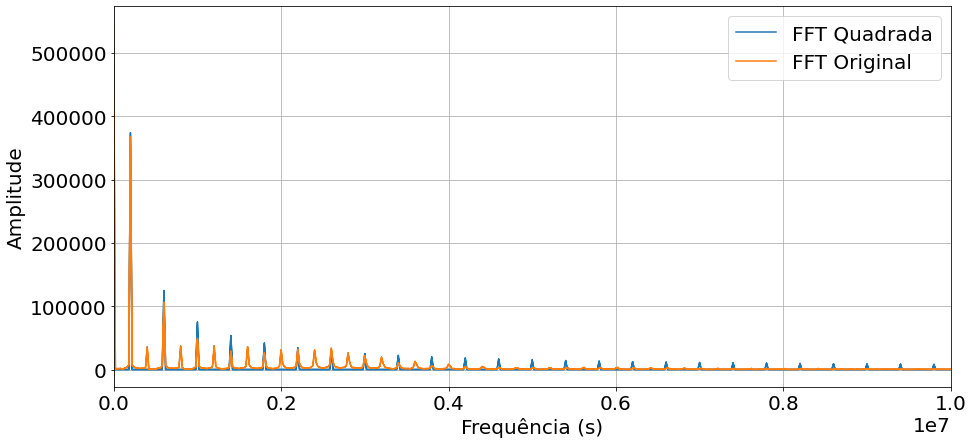

In [7]:
plt.rcParams['figure.figsize'] = [15,7]
plt.rcParams['font.size'] = 20

plt.plot(np.abs(freqs1), np.abs(fft1), np.abs(freqs2), np.abs(fft2))
plt.legend(('FFT Quadrada', 'FFT Original'))
plt.grid()
plt.xlim((0,1.5e7))
plt.xlabel('Frequência (s)')
plt.ylabel('Amplitude')
plt.xlim((0,1e7))

No handles with labels found to put in legend.


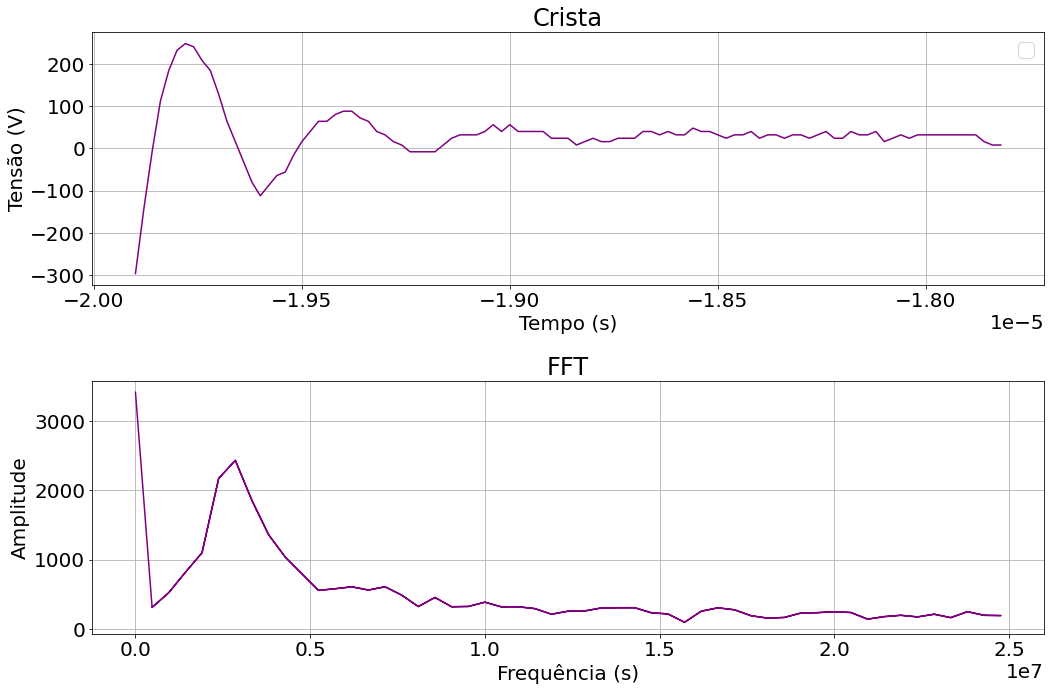

In [6]:
plt.rcParams['figure.figsize'] = [15,10]
plt.rcParams['font.size'] = 20

# Crista do sinal
d1 = 115 #ponto inicial (115)
d2 = 220 #ponto final (210)

tcris = y_exp[d1:d2,0]
ycris = y_exp[d1:d2,1]

fftCris = np.fft.fft(ycris)
freqsCris = np.fft.fftfreq(len(ycris), t[1] - t[0])

plt.subplot(2,1,1)
plt.title('Crista')
plt.plot(tcris, ycris, c='purple')
plt.legend()
plt.grid()
plt.xlabel('Tempo (s)')
plt.ylabel('Tensão (V)')

plt.subplot(2,1,2)
plt.title('FFT')
plt.plot(np.abs(freqsCris), np.abs(fftCris), c='purple')
plt.grid()
plt.xlabel('Frequência (s)')
plt.ylabel('Amplitude')

plt.tight_layout()